# Machine Learning-Driven Cross-Sectional Momentum Strategy

This project builds a monthly rebalanced equity strategy that predicts 1-month forward stock returns using momentum and volatility features. A Ridge regression model is trained on historical data and then used to rank stocks cross-sectionally. The final portfolio goes long the top-ranked names and compares unscaled and volatility-scaled performance.

## Data Collection

I use daily adjusted closing prices from Yahoo Finance for a small multi-asset equity universe. Using multiple tickers instead of a single stock makes the project more realistic and allows cross-sectional ranking, which is a common approach in quantitative equity strategies.

In [109]:
# ==============================
# Core Libraries
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Data Download
# ==============================
import yfinance as yf

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

# ==============================
# Machine Learning
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# ==============================
# Utilities
# ==============================
import warnings
warnings.filterwarnings("ignore")

# For reproducibility
np.random.seed(42)

In [110]:
# define universe and time period

tickers = ["SPY","QQQ","AAPL","MSFT","NVDA","JPM","XOM","JNJ","PG","TSLA"]

start_date = "2010-01-01"
end_date = None # defaults to current date

# Download historical data

data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Keep only the closing prices
prices = data["Close"].copy()

prices.dropna(how='all', inplace=True)

prices.head()

Ticker,AAPL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Date,,,,,,,,,,
2010-01-04,6.412383,40.204723,28.423925,23.077387,0.423784,38.146202,40.341587,85.027962,NaN,37.630966
2010-01-05,6.423470,39.738518,28.974487,23.084835,0.429972,38.158680,40.341587,85.253029,NaN,37.777912
2010-01-06,6.321295,40.061745,29.133692,22.943169,0.432722,37.977680,40.098259,85.313065,NaN,38.104412
2010-01-07,6.309611,39.775818,29.710802,22.704563,0.424242,37.771721,40.124313,85.673195,NaN,37.984703
2010-01-08,6.351559,39.912560,29.637825,22.861151,0.425159,37.721779,40.454567,85.958298,NaN,37.832329


In [111]:
prices = prices.dropna()

In [112]:
print("Shape:", prices.shape)
print("Date range", prices.index.min(), "to", prices.index.max())

Shape: (3951, 10)
Date range 2010-06-29 00:00:00 to 2026-03-13 00:00:00


In [113]:
# Compute daily returns
returns = prices.pct_change().dropna()

print("Returns shape:", returns.shape)
returns.head()

Returns shape: (3950, 10)


Ticker,AAPL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Date,,,,,,,,,,
2010-06-30,-0.018113,-0.003039,-0.012142,-0.012870,-0.025764,-0.005637,-0.015217,-0.009500,-0.002511,-0.003840
2010-07-01,-0.012126,0.000170,-0.013129,0.006519,0.016651,-0.007336,-0.002810,-0.004456,-0.078473,-0.008061
2010-07-02,-0.006198,0.000169,-0.006929,0.004749,-0.012525,-0.002688,-0.002818,-0.005449,-0.125683,-0.000707
2010-07-06,0.006844,0.000000,0.013955,0.023636,-0.010732,-0.000673,0.003061,0.006556,-0.160937,0.015733
2010-07-07,0.040381,0.025897,0.050096,0.020151,0.048324,0.024941,0.031925,0.031496,-0.019243,0.016881


## Feature Engineering

The model uses multi-horizon momentum and volatility features. Momentum is measured over 1, 3, 6, and 12 months, while 3-month volatility is included as a risk feature. These variables are standard inputs in many quantitative equity models. Momentum is approximated using rolling sums of returns, which is a standard approximation of cumulative return when daily returns are small.

In [114]:
# Momentum features
mom_1m = returns.rolling(21).sum()  # 1-month momentum
mom_3m = returns.rolling(63).sum()  # 3-month momentum
mom_6m = returns.rolling(126).sum()  # 6-month momentum
mom_12m = returns.rolling(252).sum()  # 12-month momentum

# Volatility feature

vol_3m = returns.rolling(63).std()  # 3-month rolling volatility

# Combine features into a dictionary

features = pd.concat({
    "mom_1m": mom_1m,
    "mom_3m": mom_3m,
    "mom_6m": mom_6m,
    "mom_12m": mom_12m,
    "vol_3m": vol_3m
}, axis=1)

In [115]:
features.head()

mom_1m                                         ... vol_3m          \
Ticker       AAPL JNJ JPM MSFT NVDA  PG QQQ SPY TSLA XOM  ...   AAPL JNJ JPM   
Date                                                      ...                  
2010-06-30    NaN NaN NaN  NaN  NaN NaN NaN NaN  NaN NaN  ...    NaN NaN NaN   
2010-07-01    NaN NaN NaN  NaN  NaN NaN NaN NaN  NaN NaN  ...    NaN NaN NaN   
2010-07-02    NaN NaN NaN  NaN  NaN NaN NaN NaN  NaN NaN  ...    NaN NaN NaN   
2010-07-06    NaN NaN NaN  NaN  NaN NaN NaN NaN  NaN NaN  ...    NaN NaN NaN   
2010-07-07    NaN NaN NaN  NaN  NaN NaN NaN NaN  NaN NaN  ...    NaN NaN NaN   

                                           
Ticker     MSFT NVDA  PG QQQ SPY TSLA XOM  
Date                                       
2010-06-30  NaN  NaN NaN NaN NaN  NaN NaN  
2010-07-01  NaN  NaN NaN NaN NaN  NaN NaN  
2010-07-02  NaN  NaN NaN NaN NaN  NaN NaN  
2010-07-06  NaN  NaN NaN NaN NaN  NaN NaN  
2010-07-07  NaN  NaN NaN NaN NaN  NaN NaN  

[5 rows x 50 columns]

In [116]:
features_clean = features.dropna()

features_clean.shape

(3699, 50)

In [117]:
# Convert to ML dataset format

X = features_clean.stack(level=1)
X.index.names = ['Date', 'Ticker']
X.head()

mom_1m    mom_3m    mom_6m   mom_12m    vol_3m
Date       Ticker                                                  
2011-06-28 AAPL   -0.003704 -0.040854  0.041206  0.291937  0.012596
           JNJ    -0.012358  0.118253  0.082408  0.150380  0.008982
           JPM    -0.076994 -0.141648 -0.057065  0.105628  0.012069
           MSFT    0.043264  0.023168 -0.061355  0.143799  0.012121
           NVDA   -0.224191 -0.190246  0.117717  0.514410  0.026302

## Target Construction

The target is the forward 1-month return for each stock. This lets the model learn which stocks are likely to outperform over the next rebalancing period. Care is taken to align the target correctly so no future information leaks into the features.

In [118]:
# Create target
fwd_1m = (1 + returns).rolling(21).apply(np.prod, raw=True).shift(-21) - 1  # 1-month forward return
y = fwd_1m.loc[features_clean.index].stack()
y.index.names = ["Date", "Ticker"]

# Align
data = X.join(y.rename("target")).dropna()

## Train-Test Split

The data is split chronologically rather than randomly. In financial machine learning, random train-test splits are inappropriate because they mix past and future regimes and create lookahead bias. A time-based split better reflects how a strategy would behave in real trading.

In [119]:
# Train/test split

split_date = "2018-01-01"

train = data.loc[data.index.get_level_values("Date") < split_date]
test = data.loc[data.index.get_level_values("Date") >= split_date]

In [120]:
print("Train shape:", train.shape), print("Test shape:", test.shape)

Train shape: (16390, 6)
Test shape: (20390, 6)


(None, None)

## Baseline Model

I use Ridge regression as a simple and stable baseline model. The features are standardized before fitting, and regularization helps control overfitting in a noisy financial setting where predictors are often correlated.

In [121]:
# Ridge regression model

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

X_train = train.drop(columns="target")
y_train = train["target"]

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [122]:
# Predictions
X_test = test.drop(columns="target")
test["pred"] = model.predict(X_test)

## Portfolio Construction

The model produces a predicted forward return for each stock. These predictions are used to rank stocks cross-sectionally at each rebalance date. The strategy then goes long the top three names in an equal-weighted portfolio and rebalances monthly.

In [123]:
# Cross-sectional ranking
test["rank"] = test.groupby("Date")["pred"].rank(ascending=False, method="first")
test["long"] = (test["rank"] <= 3).astype(int)

# Delay position by 1 day to avoid same-day trading
test["long"] = test.groupby("Ticker")["long"].shift(1).fillna(0).astype(int)

In [124]:
# Monthly-ish rebalance dates (every 21 trading days)
rebalance_dates = test.index.get_level_values("Date").unique()[::21]
rebalance_dates = rebalance_dates[1:]

In [125]:
# Portfolio returns only on rebalance dates
idx = pd.IndexSlice
portfolio_returns = (
    test.loc[idx[rebalance_dates, :], :]
        .query("long == 1")
        .groupby("Date")["target"]
        .mean()
)

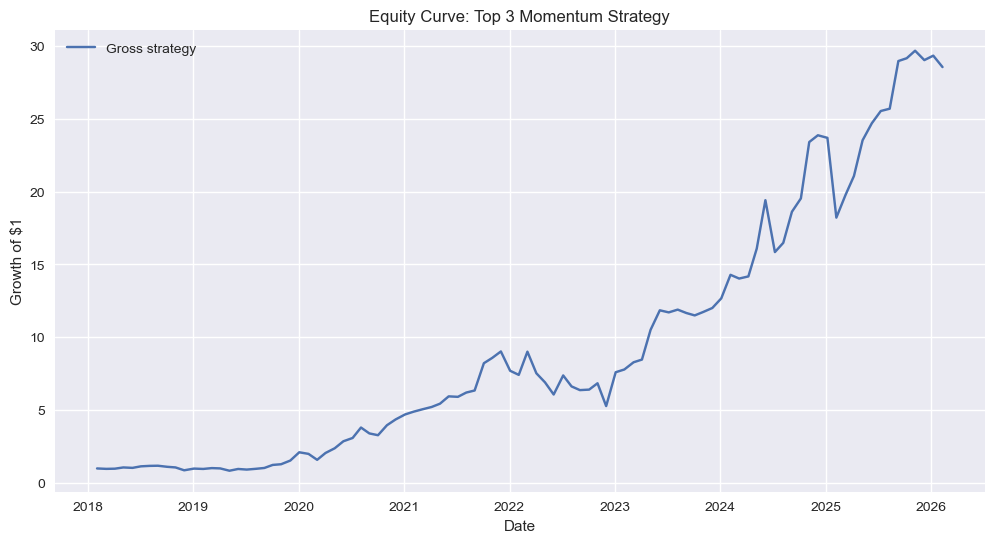

In [126]:
equity_curve = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(equity_curve, label="Gross strategy")
plt.title("Equity Curve: Top 3 Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## Transaction Costs

To make the backtest more realistic, I include a simple transaction cost adjustment. This penalizes turnover at rebalance dates and helps avoid overstating strategy performance.

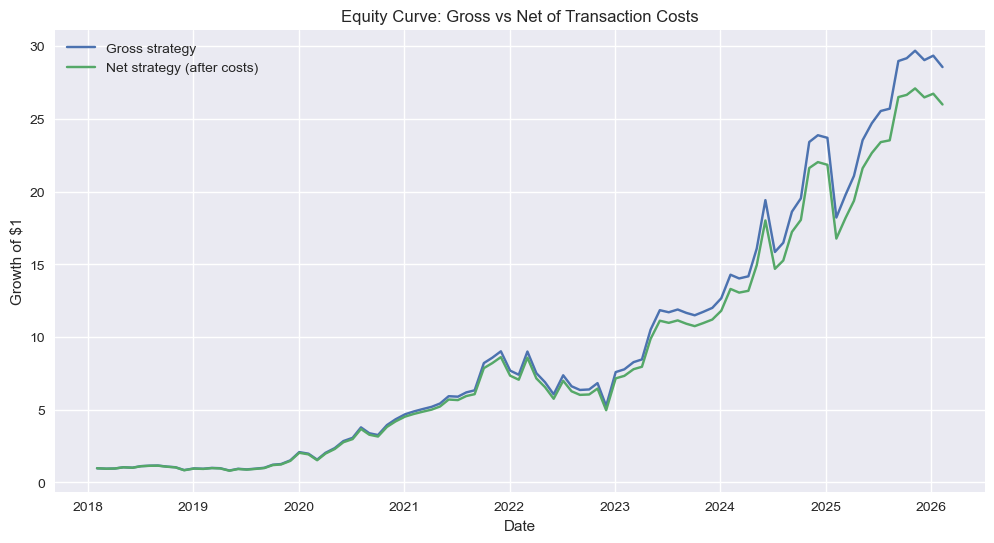

In [127]:
# Simple transaction cost model

cost_per_rebalance = 0.001  # 0.1%

portfolio_returns_net = portfolio_returns.copy()
portfolio_returns_net = portfolio_returns_net - cost_per_rebalance

equity_curve_net = (1 + portfolio_returns_net).cumprod()

plt.figure(figsize=(12,6))
plt.plot(equity_curve, label="Gross strategy")
plt.plot(equity_curve_net, label="Net strategy (after costs)")
plt.title("Equity Curve: Gross vs Net of Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## Benchmark Comparison

To evaluate whether the strategy adds value beyond a passive alternative, I compare it against an equal-weight benchmark built from the same stock universe. This helps distinguish whether the model is generating stock-selection alpha or simply benefiting from broad market exposure.

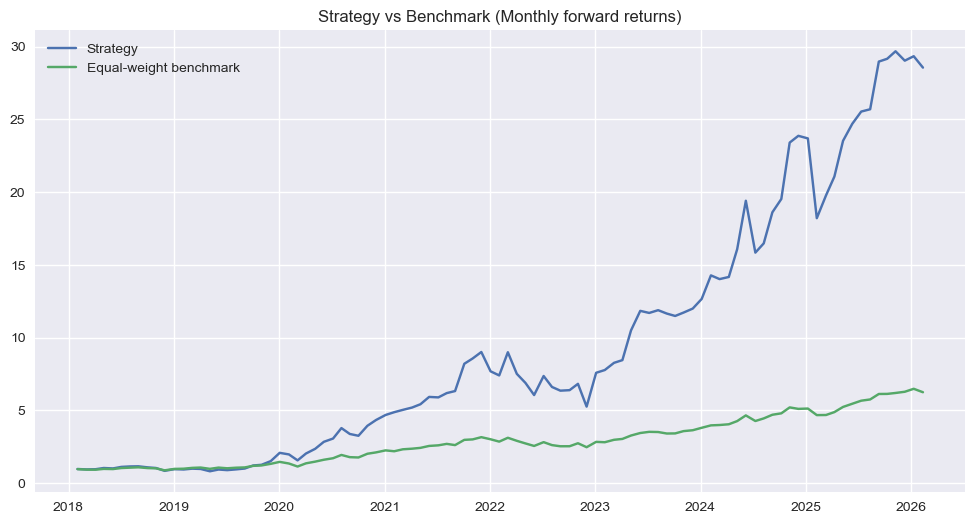

In [128]:
# equal-weight daily returns across all tickers
ew_daily = returns.mean(axis=1)

# rebalance-date “monthly” forward return for benchmark (same target definition)
ew_fwd_1m = (1 + ew_daily).rolling(21).apply(np.prod, raw=True).shift(-21) - 1

bench = ew_fwd_1m.loc[portfolio_returns.index]
bench_curve = (1 + bench).cumprod()

plt.figure(figsize=(12,6))
plt.plot(equity_curve, label="Strategy")
plt.plot(bench_curve, label="Equal-weight benchmark")
plt.legend()
plt.title("Strategy vs Benchmark (Monthly forward returns)")
plt.show()

In [129]:
# CAGR
years = len(portfolio_returns) / 12
cagr = equity_curve.iloc[-1]**(1/years) - 1

# Sharpe ratio (monthly)
sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(12)

# Max drawdown
rolling_max = equity_curve.cummax()
drawdown = equity_curve / rolling_max - 1
max_dd = drawdown.min()

print("CAGR:", round(cagr,3))
print("Sharpe:", round(sharpe,3))
print("Max Drawdown:", round(max_dd,3))

CAGR: 0.514
Sharpe: 1.198
Max Drawdown: -0.416


The high CAGR is partly driven by the concentrated tech-heavy universe and the 2020–2023 bull run, expanding the universe would likely normalize returns" shows self-awarenes.

<Axes: title={'center': 'Ridge Feature Importance'}>

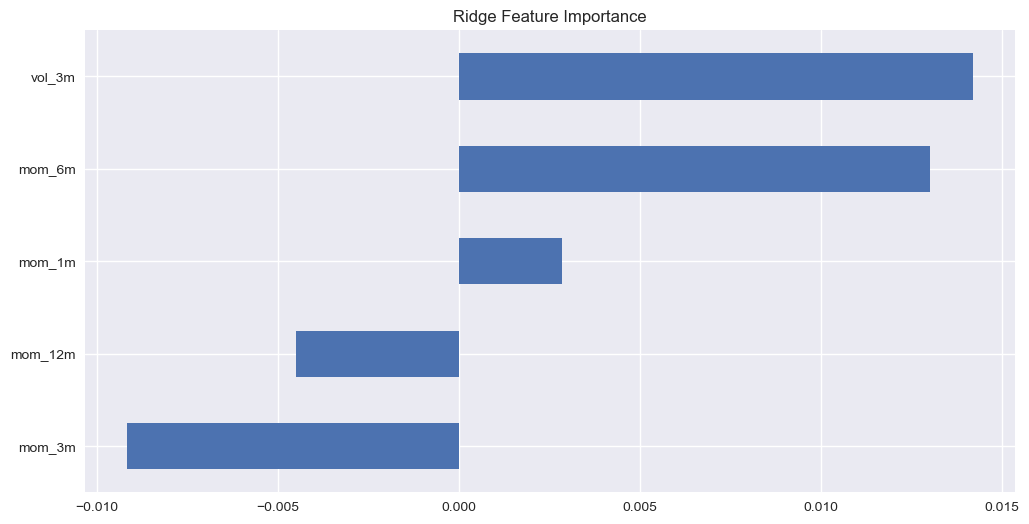

In [130]:
# Ridge coefficient importance plot
coefs = pd.Series(
    model.named_steps["ridge"].coef_,
    index=X_train.columns
).sort_values()

coefs.plot(kind="barh", title="Ridge Feature Importance")

## Volatility Scaling

Finally, I apply volatility targeting to stabilize portfolio risk. This reduces exposure when realized strategy volatility is high and increases it when volatility is low, improving drawdown control and making the strategy more risk-aware.

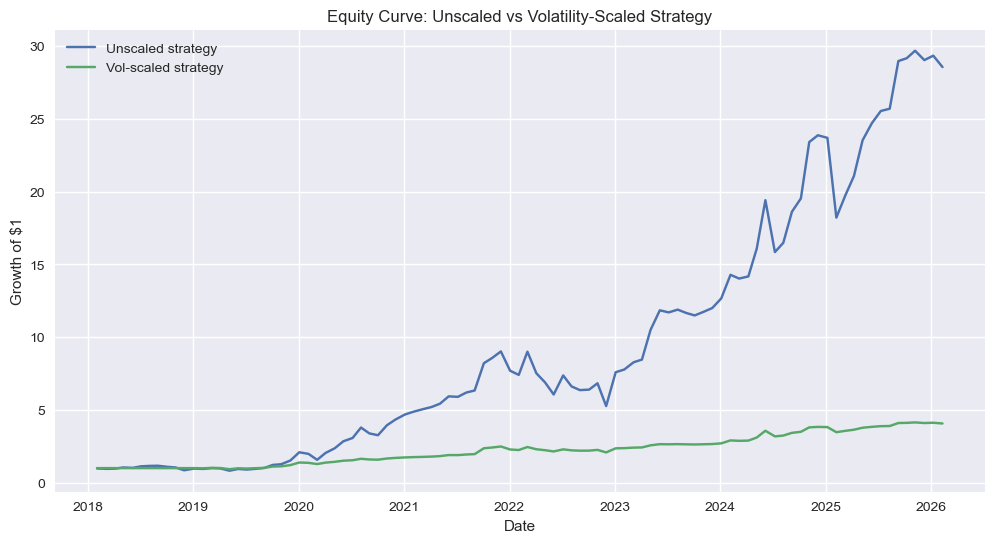

In [131]:
# Volatility scaling

target_vol = 0.15   # 15% annualized target volatility
lookback = 12       # 12 months of monthly returns
max_leverage = 2.0  # cap leverage so it doesn't explode

# Rolling realized volatility of monthly strategy returns
realized_vol = portfolio_returns.rolling(lookback).std() * np.sqrt(12)

# Scaling factor
vol_scale = target_vol / realized_vol

# Cap leverage and avoid crazy values
vol_scale = vol_scale.clip(upper=max_leverage)

# Shift by 1 period to avoid lookahead bias
scaled_returns = portfolio_returns * vol_scale.shift(1)

# Replace initial NaNs with 0 exposure
scaled_returns = scaled_returns.fillna(0)

# Scaled equity curve
equity_curve_scaled = (1 + scaled_returns).cumprod()

# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(equity_curve, label="Unscaled strategy")
plt.plot(equity_curve_scaled, label="Vol-scaled strategy")
plt.title("Equity Curve: Unscaled vs Volatility-Scaled Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [132]:
def performance_stats(returns, equity_curve, periods_per_year=12):
    years = len(returns) / periods_per_year
    cagr = equity_curve.iloc[-1]**(1 / years) - 1
    sharpe = returns.mean() / returns.std() * np.sqrt(periods_per_year)

    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    max_dd = drawdown.min()

    return pd.Series({
        "CAGR": cagr,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Final Equity": equity_curve.iloc[-1]
    })

stats_gross = performance_stats(portfolio_returns, equity_curve)
stats_net = performance_stats(portfolio_returns_net, equity_curve_net)
stats_scaled = performance_stats(scaled_returns, equity_curve_scaled)

comparison = pd.DataFrame({
    "Gross": stats_gross,
    "Net": stats_net,
    "Vol-Scaled": stats_scaled
})

comparison

,Gross,Net,Vol-Scaled
CAGR,0.513927,0.496352,0.189542
Sharpe,1.197909,1.169496,1.122263
Max Drawdown,-0.416208,-0.423558,-0.164005
Final Equity,28.565954,25.992980,4.067427


## Performance Visualization

In addition to the equity curve and summary statistics, I use a monthly return heatmap to visualize return consistency over time. This makes it easier to see whether performance is concentrated in a few periods or more evenly distributed.

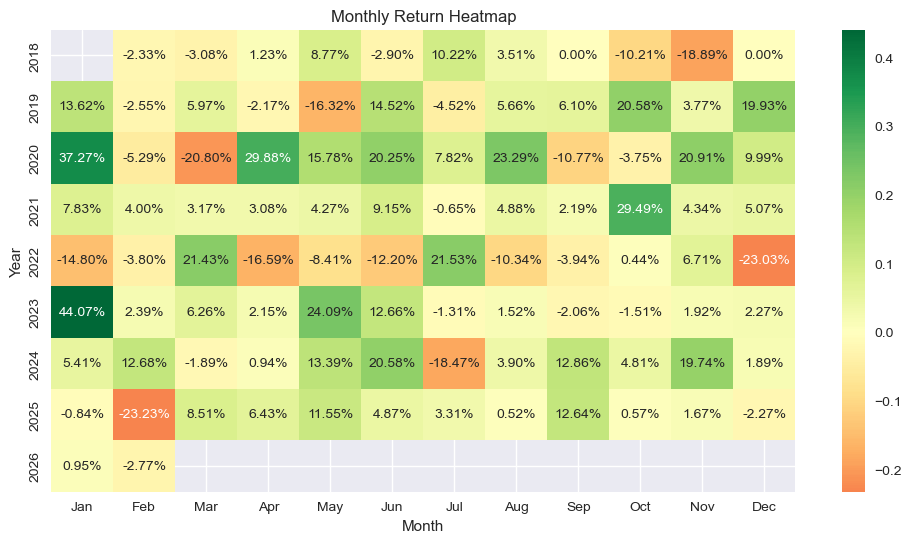

In [133]:
# Monthly returns heatmap

# Convert daily returns to monthly returns
monthly_returns = portfolio_returns_net.resample("M").apply(lambda x: (1 + x).prod() - 1)

heatmap_df = monthly_returns.to_frame(name="return")

heatmap_df["Year"] = heatmap_df.index.year
heatmap_df["Month"] = heatmap_df.index.strftime("%b")

heatmap_table = heatmap_df.pivot(index="Year", columns="Month", values="return")

# Order months correctly
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

heatmap_table = heatmap_table.reindex(columns=month_order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_table, annot=True, fmt=".2%", cmap="RdYlGn", center=0)

plt.title("Monthly Return Heatmap")
plt.show()

## Conclusion

The final strategy demonstrates a complete quantitative research workflow: data collection, feature engineering, target construction, machine learning prediction, cross-sectional ranking, portfolio construction, and risk management. While the unscaled strategy produced the strongest raw returns, volatility scaling significantly reduced drawdowns and made the risk profile more stable. A natural next step would be expanding the stock universe and testing additional models and weighting schemes.